# CENG501 Deep Learning - HW1

Fall 2025

Instructor: Dr. Emre Akbas

31.10.2025

IMPORTANT COPYRIGHT NOTICE: **You are not allowed to share** this document with anybody else. For example, you should not publish it on your publicly accessible webpages or GitHub repositories.

IMPORTANT NOTE: **What you submit should be your own work!** You may  use large language models (LLMs) or other AI-assisted tools for this assignment. However, **learning** the concepts and skills covered by this homework **is your responsibility**. You are expected to understand and be able to explain any code or solution you submit. By submitting your work, you acknowledge full responsibility for its content and correctness—regardless of whether it was produced with or without AI assistance.

By submitting your solution to this assignment, you agree to the METU Code of Honor:



> “As reliable, responsible and honorable individuals, all members of Middle East Technical University embrace only the success and recognition they deserve, and act with integrity in the use, evaluation and presentation of facts, data and documents.”


Good luck!




## Description

This programming homework has three parts. In the first part, you will build, train and test a MLP network for a 2D synthetic dataset. In the second part, you will develop an encoder-decoder  CNN architecture for image reconstruction and use the encoder part for further training a classifier. You will be using the MNIST dataset. And in the last part, you will develop a character based sequence to sequence RNN network that can do integer arithmentic.

The first part is 25 points, the second part is 35 points and the last part is 40 points.

# PART 1
In this part, you will build, train and test a MLP. Your MLP should give a reasonable accuracy (better than chance level) on the test set.

Follow the instructions below.

**The parts that you are expected to code are marked with "YOUR CODE HERE". You are not allowed to change other parts of the code.**

In [1]:
# Let's first import required modules
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification


In [2]:
# we will use the Moons and Circles datasets from Scikit-learn.

# Let's create two datasets
moons = make_circles(1000, random_state=0,factor=0.5, noise=0.1)
circles = make_moons(1000, random_state=0, noise=0.1)


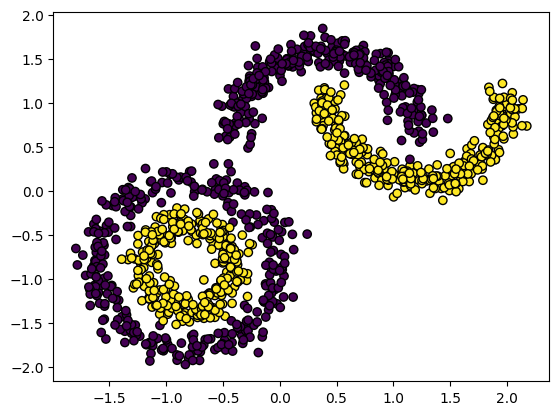

In [3]:
# Here, we will combine these two datasets to make it a more challenging problem.
X, y = moons
X1,y1 = circles
X = np.vstack((X,X1+1.5))
y = np.hstack((y,y1))

# pre-proces data
X = StandardScaler().fit_transform(X)

# split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
    )

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Plot the training points
ax = plt.axes()
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,  edgecolors="k")

## Task 1

Define  a multilayer perceptron network class using PyTorch. Its class name should be "MLP".

Create an instance from this class; its name should be "mlp".

In [4]:
# YOUR CODE HERE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

mlp = MLP()


## Task 2

Define the loss function and the optimizer. Use binary cross-entropy loss. The choice of the optimizer is up to you.

In [5]:
# YOUR CODE HERE
loss_fn = nn.BCELoss()
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

## Task 3

Create train dataloader and test dataloader from the dataset splits that we created above. The dataloaders should be instances of the "DataLoader" class in PyTorch. (Hint: there is an example at https://www.kaggle.com/code/glebbuzin/solving-sklearn-datasets-with-pytorch)

In [6]:
# YOUR CODE HERE
X_train_t = torch.from_numpy(X_train).to(torch.float32)
y_train_t = torch.from_numpy(y_train).to(torch.float32)
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)

X_test_t = torch.from_numpy(X_test).to(torch.float32)
y_test_t = torch.from_numpy(y_test).to(torch.float32)
test_dataset = TensorDataset(X_test_t, y_test_t)

test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

## Task 4

Train your "mlp". This code should also plot the training loss versus iterations (or epochs -- up to you).

In [7]:
# YOUR CODE HERE
max_epochs = 200
loss_history = []

mlp.train()
for epoch in range(max_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = mlp(x_batch).squeeze()
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    avg_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:3d}/{max_epochs} - Train Loss: {avg_loss:.4f}")


Epoch  20/200 - Train Loss: 0.1054
Epoch  40/200 - Train Loss: 0.0293
Epoch  60/200 - Train Loss: 0.0162
Epoch  80/200 - Train Loss: 0.0111
Epoch 100/200 - Train Loss: 0.0087
Epoch 120/200 - Train Loss: 0.0079
Epoch 140/200 - Train Loss: 0.0070
Epoch 160/200 - Train Loss: 0.0058
Epoch 180/200 - Train Loss: 0.0046
Epoch 200/200 - Train Loss: 0.0040


The following code runs your "mlp" on a meshgrid of points and plots the result on this grid. It visualizes the decision boundary (and regions) for your "mlp".

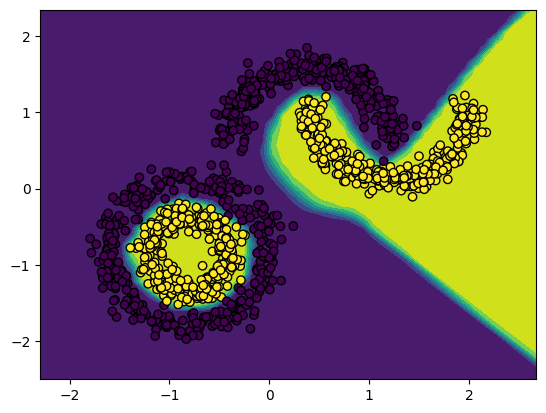

In [8]:
xs, ys = np.meshgrid(np.linspace(x_min, x_max), np.linspace(y_min, y_max))
gr_data = np.float32(np.vstack((xs.flatten(), ys.flatten())).transpose())
gr_out = mlp(torch.from_numpy(gr_data))
gr_out = gr_out.detach().numpy().reshape(xs.shape)

ax = plt.axes()
ax.contourf(xs,ys,gr_out, )
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,  edgecolors="k")

## Task 5

Evaluate your trained "mlp" on the test set. This piece of code should print out the percentage of correctly predicted test points. This is your test accuracy.

In [11]:
# YOUR CODE HERE
mlp.eval()
correct = 0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        preds = mlp(x_batch).squeeze()
        predicted_labels = (preds >= 0.5).float()
        correct += (predicted_labels == y_batch).sum().item()

test_accuracy = correct / len(test_loader.dataset)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
mlp.train()


Test accuracy: 98.88%


MLP(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

## Task 6 (final task)

Now do a grid search on the learning rate to improve your test accuracy. Try at least three different learning rates. The search should be done on a validation set that is separate from the test set. You can spare 20% of the training set to obtain your validation set.  

In [ ]:
# YOUR CODE HERE
import pandas as pd
from IPython.display import Markdown

torch.manual_seed(0)
np.random.seed(0)

X_sub_train, X_val, y_sub_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

def make_loader(features, labels, batch_size=64, shuffle=True):
    tensor_x = torch.from_numpy(features).float()
    tensor_y = torch.from_numpy(labels).float()
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

sub_train_loader = make_loader(X_sub_train, y_sub_train)
val_loader = make_loader(X_val, y_val, shuffle=False)
full_test_loader = make_loader(X_test, y_test, shuffle=False)


def train_one_model(lr, epochs=200):
    model = MLP()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses = []

    for _epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in sub_train_loader:
            optimizer.zero_grad()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        train_losses.append(epoch_loss / len(sub_train_loader.dataset))

    return model, train_losses[-1]


def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            preds = model(xb).squeeze()
            predicted = (preds >= 0.5).float()
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
    model.train()
    return correct / total

learning_rates = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
results = []

for lr in learning_rates:
    model, final_loss = train_one_model(lr)
    val_acc = evaluate_accuracy(model, val_loader)
    test_acc = evaluate_accuracy(model, full_test_loader)
    results.append({
        "Learning rate": lr,
        "Final training loss": final_loss,
        "Validation accuracy": val_acc,
        "Test accuracy": test_acc
    })
    print(f"lr={lr:.4f} | train_loss={final_loss:.4f} | val_acc={val_acc*100:.2f}% | test_acc={test_acc*100:.2f}%")

results_df = pd.DataFrame(results)
results_markdown = results_df.to_markdown(index=False)
print(results_markdown)
Markdown(results_markdown)


lr=0.0001 | train_loss=0.0751 | val_acc=97.92% | test_acc=98.38%
lr=0.0005 | train_loss=0.0067 | val_acc=99.58% | test_acc=99.25%
lr=0.0010 | train_loss=0.0068 | val_acc=99.58% | test_acc=99.62%
lr=0.0050 | train_loss=0.0015 | val_acc=99.58% | test_acc=99.25%
lr=0.0100 | train_loss=0.0039 | val_acc=99.58% | test_acc=99.50%
|   Learning rate |   Final training loss |   Validation accuracy |   Test accuracy |
|----------------:|----------------------:|----------------------:|----------------:|
|          0.0001 |            0.0750737  |              0.979167 |         0.98375 |
|          0.0005 |            0.00673011 |              0.995833 |         0.9925  |
|          0.001  |            0.00676182 |              0.995833 |         0.99625 |
|          0.005  |            0.00149838 |              0.995833 |         0.9925  |
|          0.01   |            0.0038851  |              0.995833 |         0.995   |


|   Learning rate |   Final training loss |   Validation accuracy |   Test accuracy |
|----------------:|----------------------:|----------------------:|----------------:|
|          0.0001 |            0.0750737  |              0.979167 |         0.98375 |
|          0.0005 |            0.00673011 |              0.995833 |         0.9925  |
|          0.001  |            0.00676182 |              0.995833 |         0.99625 |
|          0.005  |            0.00149838 |              0.995833 |         0.9925  |
|          0.01   |            0.0038851  |              0.995833 |         0.995   |

Report your results by completing the table below.

| Learning rate (lr) | Final training loss | Validation set accuracy | Test set accuracy |
| ---                | ---                 | ---               | ---
| lr1= 0.001 | 0.00676182 | 0.995833 | 0.99625 |
| lr2= 0.01 | 0.0038851 | 0.995833 | 0.995 |
| lr3= 0.005 | 0.00149838 | 0.995833 | 0.9925 |



# PART 2
In this part, you will work on developing an encoder-decoder (see figure below) CNN architecture for image reconstruction and use the encoder part for further training a classifier. You will be using the MNIST dataset.

**The parts that you are expected to code are marked with "YOUR CODE HERE". You are not allowed to change other parts of the code.**

You will design an encoder CNN which maps a given MNIST image (28x28 image) to a HxWxC dimensional image. Here $H\cdot W\cdot C$ should be less than 64. Then, you will also design a decoder CNN which will take this HxWxC image and output a 28x28 image.

Note that in this  description, batch size is 1 for ease of illustration. Batch size is not 1 in the tasks below.  


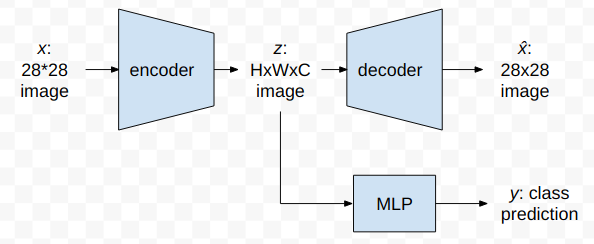

Next, you will design a classifier MLP that takes the HxWxC dimensional encoder output and predicts its category.

These three networks will be trained in different ways as explained in the tasks below.

In [14]:
# Import the required modules
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [15]:
# Define the "device". If GPU is available, device is set to use it, otherwise CPU will be used.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Make sure you select "GPU" or "TPU" as the Hardware Accelarator, which is accesible from the "Rutime -> Change runtime type" menu.

In [16]:
# Download the dataset
train_data = datasets.MNIST(root = './data', train = True,
                        transform = transforms.ToTensor(), download = True)

test_data = datasets.MNIST(root = './data', train = False,
                       transform = transforms.ToTensor())

100.0%
100.0%
100.0%
100.0%


In [ ]:
# About the ToTensor() transformation.

# PyTorch networks expect a tensor as input with dimensions N*C*H*W  where
# N: batch size
# C: channel size
# H: height
# W: width

# Normally an image is of size H*W*C.
# ToTensor() transformation moves the channel dimension to the beginning as needed by PyTorch.

In [ ]:
# Define the data loaders
batch_size = 100
train_loader = torch.utils.data.DataLoader(dataset = train_data,
                                             batch_size = batch_size,
                                             shuffle = True)

test_loader = torch.utils.data.DataLoader(dataset =  test_data ,
                                      batch_size = batch_size,
                                      shuffle = False)

## Task 1

Define the Encoder CNN. It will accept a Nx1x28x28 input tensor (where N is the batch size) and output a NxCxHxW tensor. $H\cdot W \cdot C$ should be less than 64, e.g. H=4, W=4 and C=3. You can use conv2d, relu and pooling layers as necessary.

In [ ]:
# Define the encoder CNN

class Encoder(nn.Module):
    #This defines the structure of the NN.
    def __init__(self):
        super(Encoder, self).__init__()
        # YOUR CODE HERE

    def forward(self, x):
        # YOUR CODE HERE

Let's create an instance of Encoder and run it on a random input tensor to see if it outputs the expected dimensions.

In [ ]:
# Create an instance
encoder = Encoder().to(device)

x = torch.randn(20, 1, 28, 28).to(device)
y = encoder(x)
print(x.shape)
print(y.shape)  # this should print "torch.Size([20, 3, 4, 4])"

torch.Size([20, 1, 28, 28])
torch.Size([20, 3, 4, 4])


## Task 2
Define the Decoder CNN. It will accept NxCxHxW dimensional input tensor and will output Nx1x28x28 dimensional tensor.  Use "deconvolution" layers, which are implemented by the `ConvTranspose2d` function in PyTorch. You might need to set `stride` and `output_padding` values to adjust dimensions.

In [ ]:
class Decoder(nn.Module):
  def __init__(self):
    super(Decoder, self).__init__()
    # YOUR CODE HERE

  def forward(self, x):
    # YOUR CODE HERE

Let's create an instance of Decoder and run it on a random input tensor to see if it outputs the expected dimensions.

In [ ]:
# Create an instance
decoder = Decoder().to(device)

x = torch.randn(20, 3, 4, 4).to(device)
y = decoder(x)
print(x.shape)
print(y.shape) # this should print "torch.Size([20, 1, 28, 28])"

torch.Size([20, 3, 4, 4])
torch.Size([20, 1, 28, 28])


## Task 3

Train the encoder and decocer simultaneously to minimize the mean squared error (MSE), that is

$$L = \frac{1}{M}\sum_{i=1} (x_i - \hat{x}_i)^2 $$

where $M$ is the number of all examples in the training set.

In [ ]:
# Define the loss function and the optimizer
loss_fun = # YOUR CODE HERE
params = # YOUR CODE HERE
optimizer = torch.optim.Adam( params, lr=1.e-3)

In [ ]:
# Train the model

num_epochs = 5
loss_history = []
for epoch in range(num_epochs):
  for i ,(images,labels) in enumerate(train_loader):
    images = images.to(device)

    optimizer.zero_grad()
    latent = encoder(images)
    rec = decoder(latent)
    loss = loss_fun(rec, images)
    loss.backward()
    optimizer.step()

    if (i+1) % batch_size == 0:
      loss_history.append(loss.item())
      print('Epoch [%d/%d], Step [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, len(train_data)//batch_size, loss.item()))

In [ ]:
import matplotlib.pyplot as plt
plt.plot(loss_history)

Show an example $x$ and its correspoinding $\hat{x}$.

In [ ]:
plt.imshow(images[0,0,].cpu().numpy())
plt.show()
plt.imshow(rec[0,0,].detach().cpu().numpy())
plt.show()

## Task 4

Define the classifier MLP and train on encoder outputs. It should accept NxCxHxW tensor and output Nx10 tensor. Note that 10 is the number of classes in MNIST.

Hint: it should first flatten the CxHxW part.

Regarding the architecture of the MLP: just one hidden layer is sufficient but more layers are fine. The design is up to you.

In this task, **only the MLP part should be trained**.

In [ ]:
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    # YOUR CODE HERE

  def forward(self, x):
    # YOUR CODE HERE

# Create an instance
mlp = MLP().to(device)

print(mlp)
x = torch.randn(20, 3, 4, 4).to(device)
y = mlp(x)
y.shape

In [ ]:
# Define the loss function and the optimizer
loss_fun = # YOUR CODE HERE
params = # YOUR CODE HERE
optimizer = torch.optim.Adam(params, lr=1.e-3)

In [ ]:
# Train the model
num_epochs = 2
loss_history = []
for epoch in range(num_epochs):
  for i ,(images,labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    latent = encoder(images)
    output = mlp(latent)
    loss = loss_fun(output, labels)
    loss.backward()
    optimizer.step()

    if (i+1) % batch_size == 0:
      loss_history.append(loss.item())
      print('Epoch [%d/%d], Step [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, len(train_data)//batch_size, loss.item()))


plt.plot(loss_history)

In [ ]:
def evaluate(encoder, classifier):
  # Run the trained model on the testing set
  correct = 0
  total = 0
  for images,labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    out = classifier(encoder(images))
    _, predicted_labels = torch.max(out,1)
    correct += (predicted_labels == labels).sum()
    total += labels.size(0)

  print('Percent correct: %.3f %%' %((100*correct)/(total+1)))


evaluate(encoder, mlp)

## Task 5

Finally, create new instances of encoder and MLP networks and train them jointly.

In [ ]:
# Define the loss function and the optimizer
new_net1 = Encoder().to(device)
new_net2 = MLP().to(device)

loss_fun = nn.CrossEntropyLoss()
params = # YOUR CODE HERE
optimizer = torch.optim.Adam( params, lr=1.e-3)

#@title

num_epochs = 2
loss_history = []
for epoch in range(num_epochs):
  for i ,(images,labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    latent = new_net1(images)
    output = new_net2(latent)
    loss = loss_fun(output, labels)
    loss.backward()
    optimizer.step()

    if (i+1) % batch_size == 0:
      loss_history.append(loss.item())
      print('Epoch [%d/%d], Step [%d/%d], Loss: %.4f'
                 %(epoch+1, num_epochs, i+1, len(train_data)//batch_size, loss.item()))

plt.plot(loss_history)



In [ ]:
# Run the trained model on the testing set
evaluate(new_net1, new_net2)

## Task 6 (final task)

Compare the loss plots and test accuracies obtained in tasks 4 and 5. Before doing the experiments, which one did you expect to perform better? Why? Are the results as you expected?

YOUR ANSWER HERE: ___


# PART 3
In this part, you will develop a RNN model (using PyTorch LSTM) that can do integer arithmetic. Your model should take a string that contains an arithmetic operation, consume it character by character, and then return the result of the arithmetic operation again character by character.

Example input-output (i.e. target) sequences:

- Input: `"3+5"`, output: `"8"`
- Input: `"35+10"`, output: `"45"`
- Input: `"10-20"`, output: `"-10"`

We implemented such a model in a previous of this course. You can access the code at https://colab.research.google.com/drive/1-Fgh-bZd7gEwJyoF5HqF8Z6V0Jr7j1fM?usp=sharing But this code was written in Keras.

Here you have two tasks:

1. Implement the same model  in PyTorch. Demonstrate that it is learning by showing a train loss vs epochs plot. Include example inference outputs to demonstrate that your model works.
2. The previous implementation only covers addition and subtraction operations. Add multiplication and division operations to the dataset. And retrain your model. Again, show train loss plot and example outputs to demonstrate that your model learned something meaningful. For division by zero, your model should return "NaN". That is, for the string "3/0" as input, your model should return the string "NaN".

You can reuse code from https://colab.research.google.com/drive/1-Fgh-bZd7gEwJyoF5HqF8Z6V0Jr7j1fM?usp=sharing and you can create as many code or text blocks as you want.

In [ ]:
# YOUR CODE HERE